# Principal Component Analysis with Cancer Data

In [179]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [180]:
cancer_df = pd.read_csv('./cancer.csv')

In [181]:
cancer_df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [182]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done
cancer_df = cancer_df.drop('ID', axis=1)
cancer_df.head()    

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [183]:
cancer_df.shape

(699, 10)

In [184]:
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(9), object(1)
memory usage: 54.7+ KB


In [185]:
#descriptive stats
cancer_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ClumpThickness,699,NaN,NaN,NaN,4.41774,2.81574,1,2,4,6,10
Cell Size,699,NaN,NaN,NaN,3.13448,3.05146,1,1,1,5,10
Cell Shape,699,NaN,NaN,NaN,3.20744,2.97191,1,1,1,5,10
Marginal Adhesion,699,NaN,NaN,NaN,2.80687,2.85538,1,1,1,4,10
Single Epithelial Cell Size,699,NaN,NaN,NaN,3.21602,2.2143,1,2,2,4,10
Bare Nuclei,699,11,1,402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Normal Nucleoli,699,NaN,NaN,NaN,3.43777,2.43836,1,2,3,5,10
Bland Chromatin,699,NaN,NaN,NaN,2.86695,3.05363,1,1,1,4,10
Mitoses,699,NaN,NaN,NaN,1.58941,1.71508,1,1,1,1,10
Class,699,NaN,NaN,NaN,2.68956,0.951273,2,2,2,4,4


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [186]:
cancer_df["Bare Nuclei"] = cancer_df["Bare Nuclei"].replace('?',0).astype('int64')
cancer_df["Bare Nuclei"] = cancer_df["Bare Nuclei"].replace(0,round(cancer_df["Bare Nuclei"].mean())).astype('int64')

In [187]:
# Check for missing value in any other column
cancer_df.isnull().values.any()

False

In [188]:
# No missing values found. So let us try to remove ? from bare nuclei column
# Get count of rows having ?
cancer_df.shape

(699, 10)

In [189]:
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null int64
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(10)
memory usage: 54.7 KB


# Q4. Perform bi variate analysis including correlation & pairplots. 


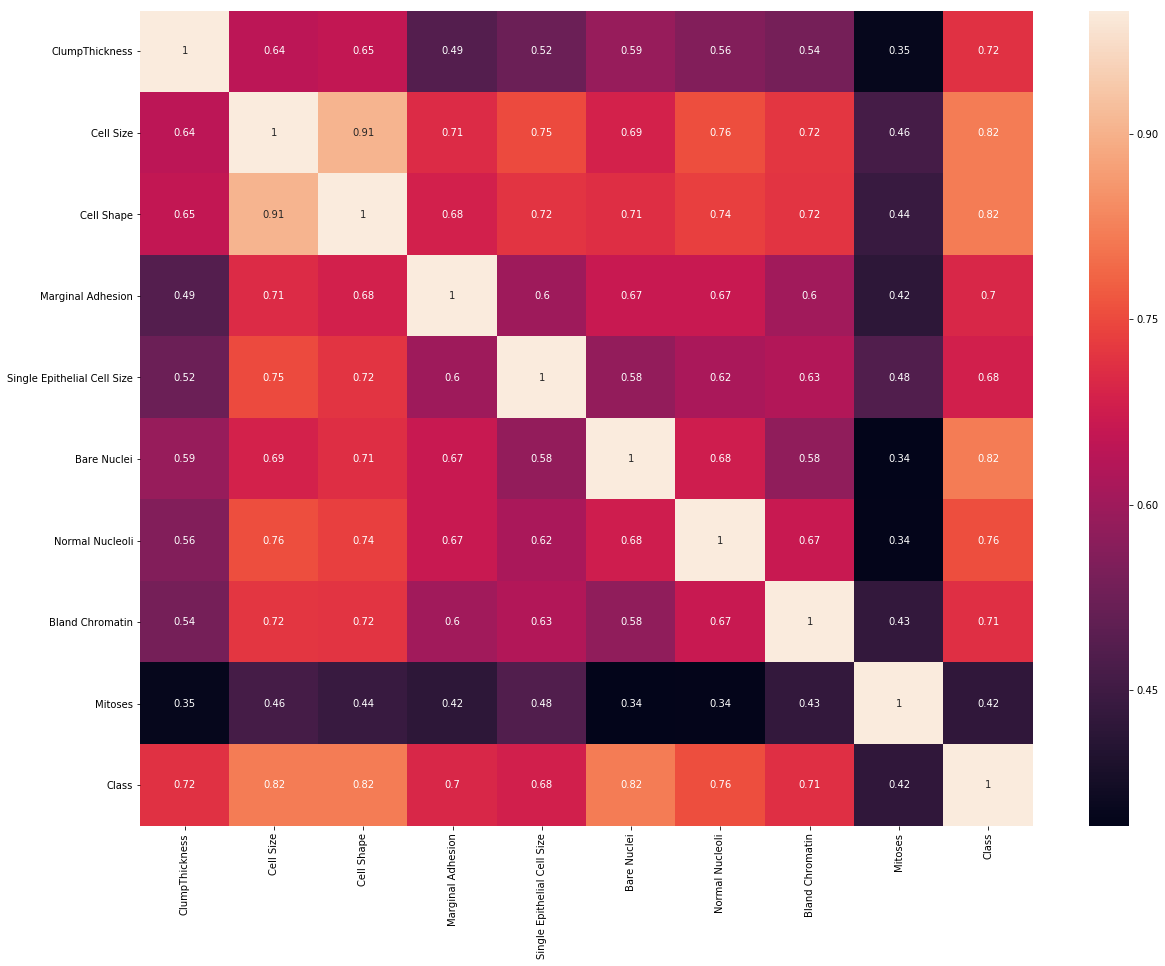

In [190]:
# Check for correlation of variable
plt.subplots(figsize=(20,15))
sns.heatmap(cancer_df.corr(), annot=True)


C:\Users\ojhaj\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\Users\ojhaj\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


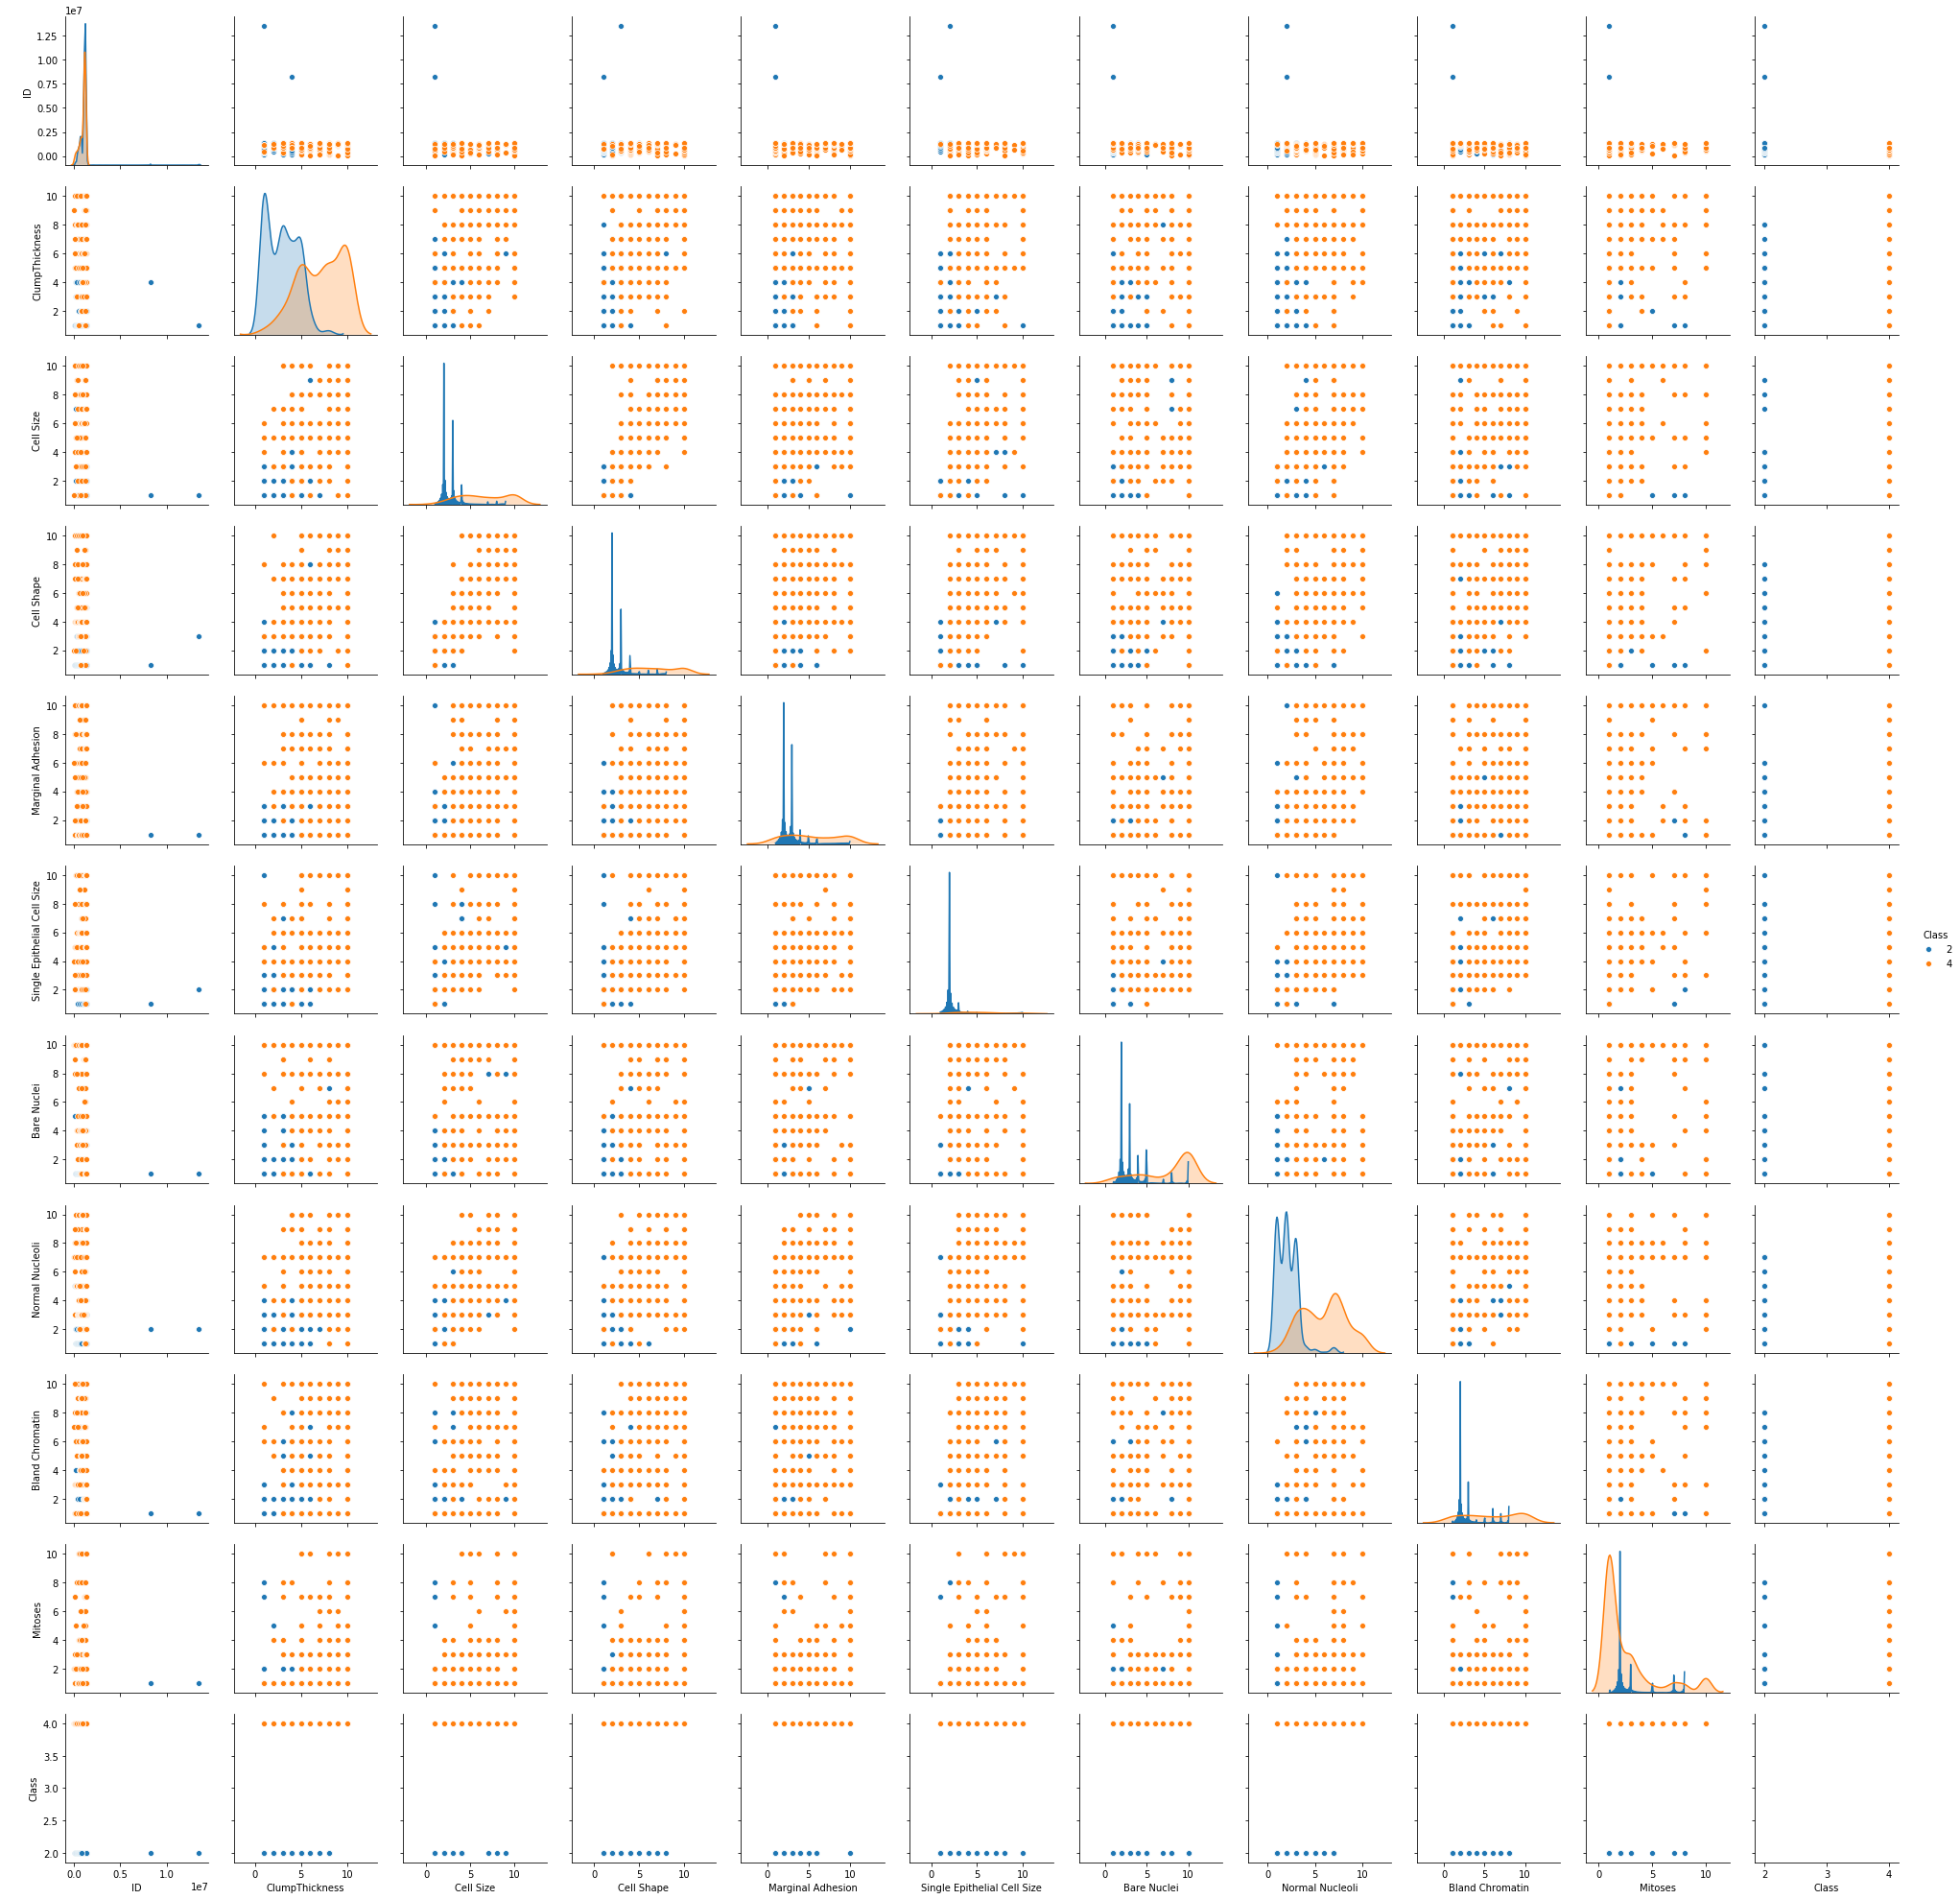

In [191]:
#Let us check for pair plots
sns.pairplot(new_cancer_df,diag_kind='kde', hue='Class')

In [192]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [193]:
def show_quant_feature_hist_plot(df, cut_pts=40, fig_height=15, fig_len=20):
    #defaul
    descr_trans_df = df.describe()
    for feature in list(descr_trans_df.T.index):
        bins = np.linspace(descr_trans_df[feature]['min'], descr_trans_df[feature]['max'], cut_pts)
        plt.subplots(figsize=(fig_len,fig_height))
        #pyplot.hist(df[feature], bins, alpha=0.5, normed=True, label=str(feature)) 
        plt.hist(df[feature], bins, alpha=0.5, label=str(feature))
        plt.legend(loc='upper right')
        plt.show()

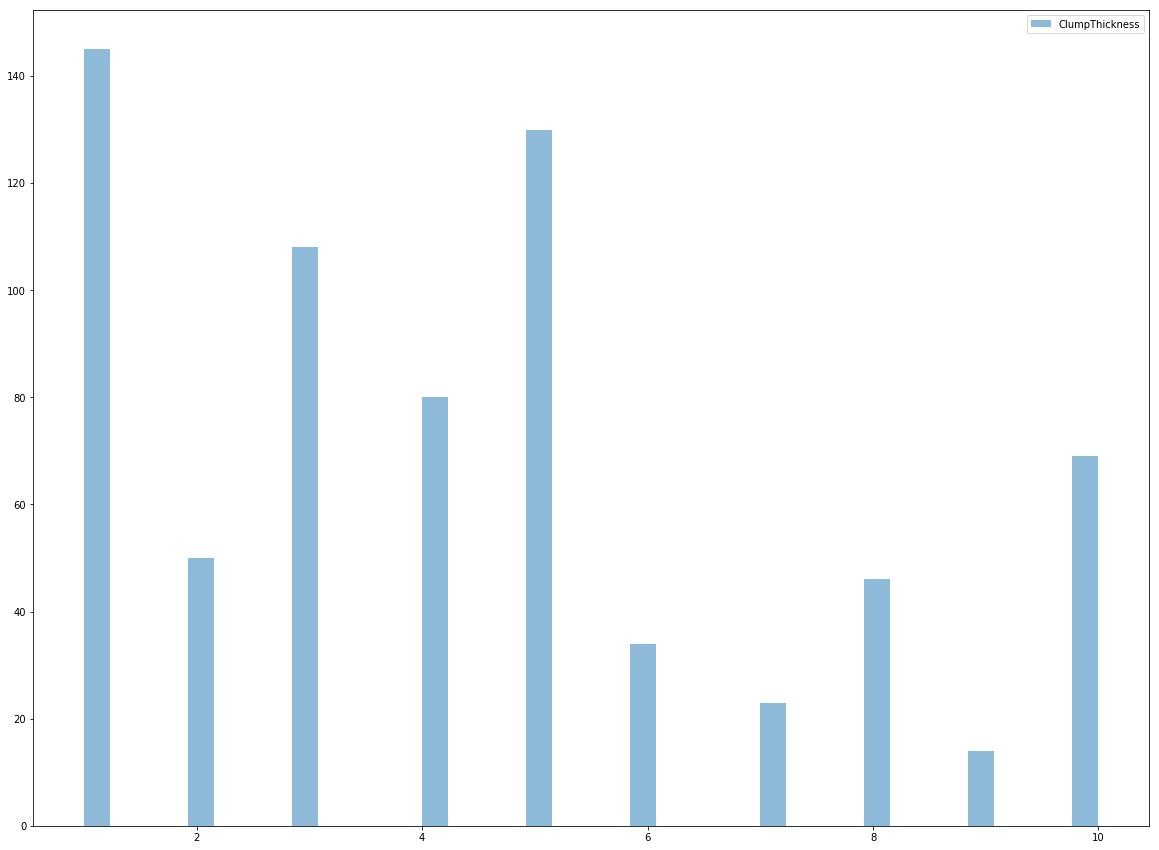

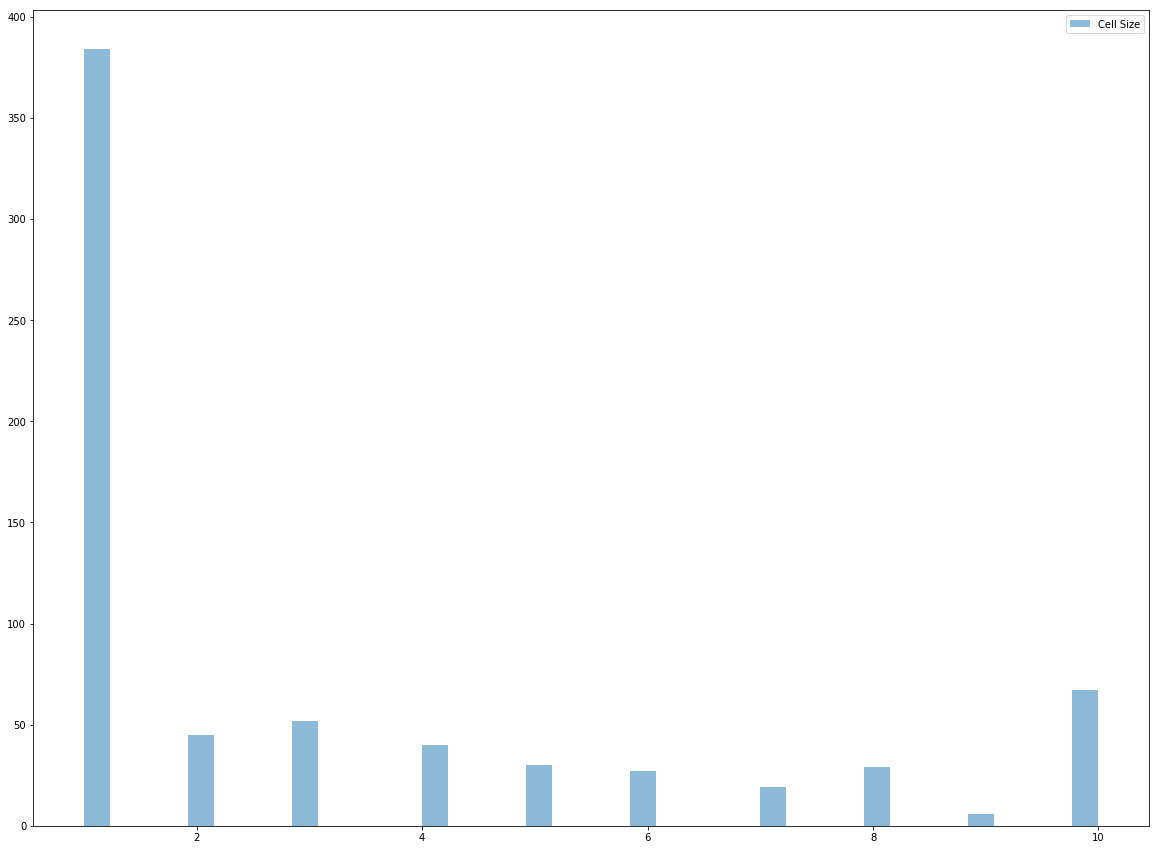

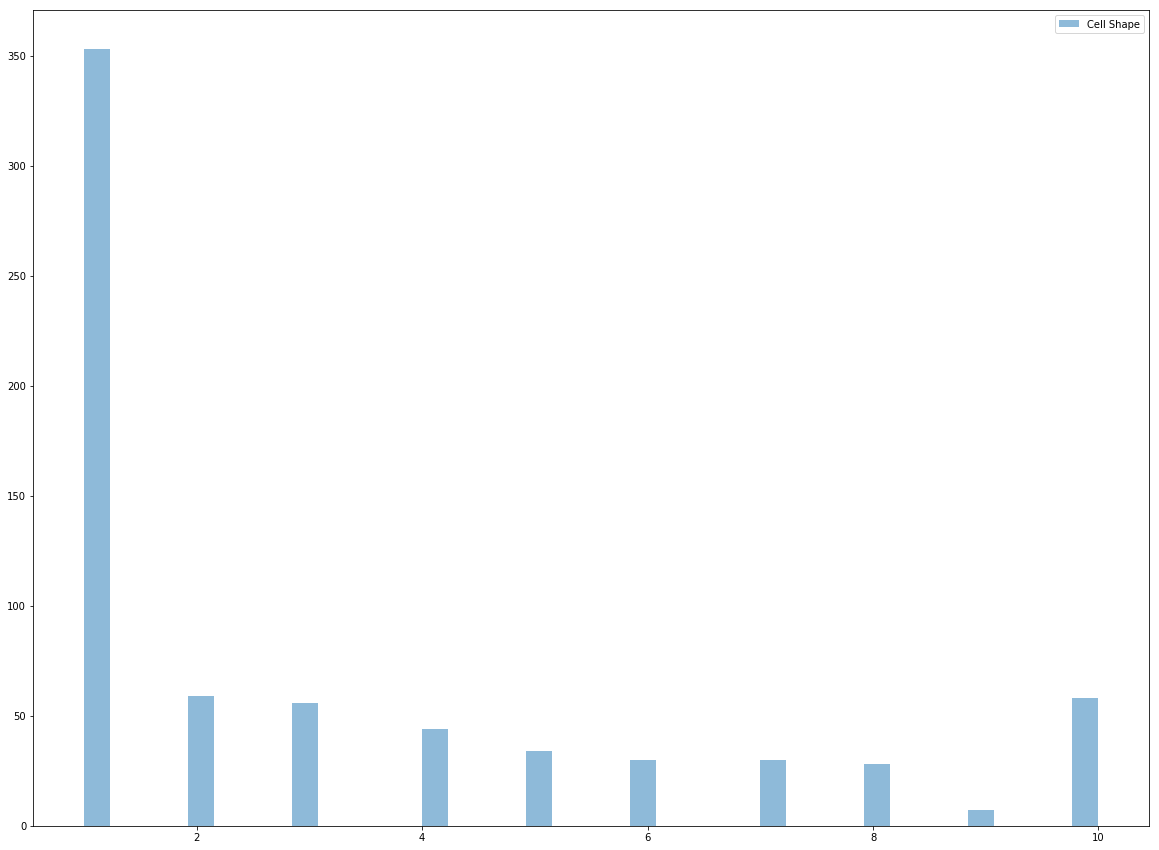

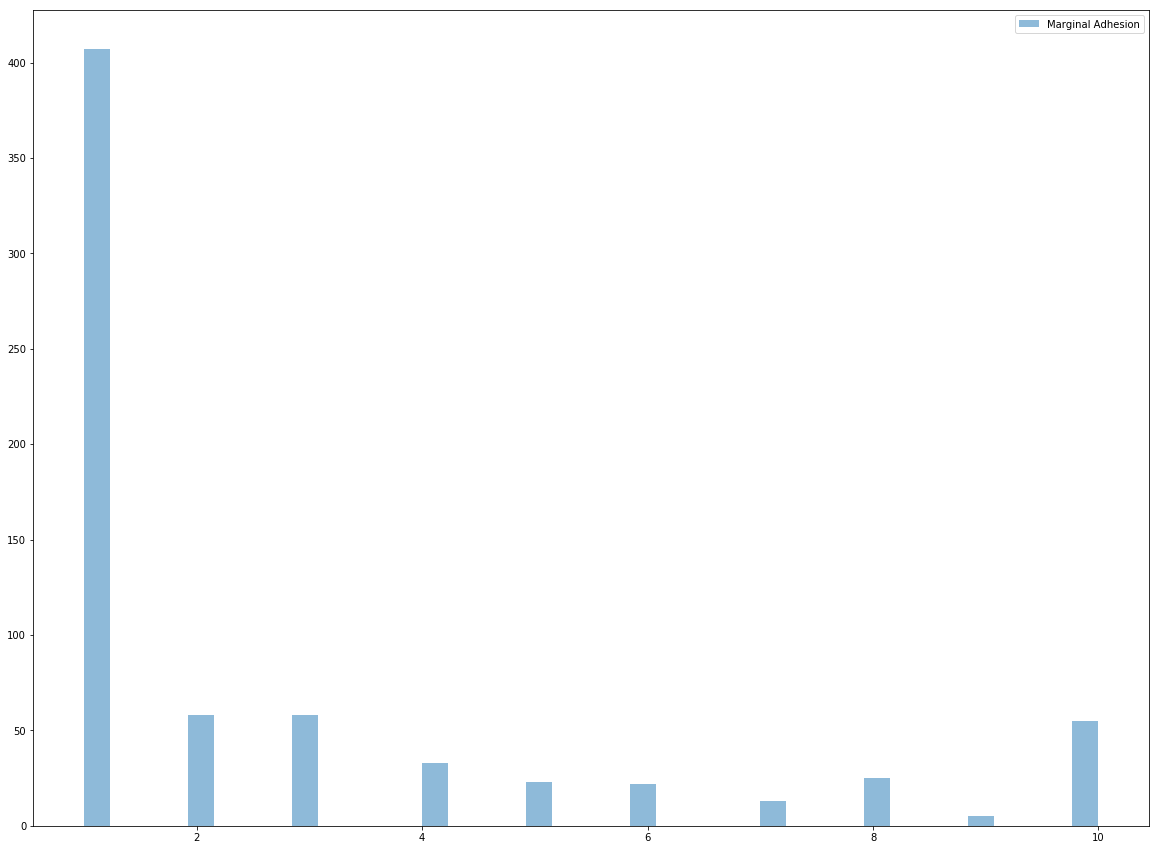

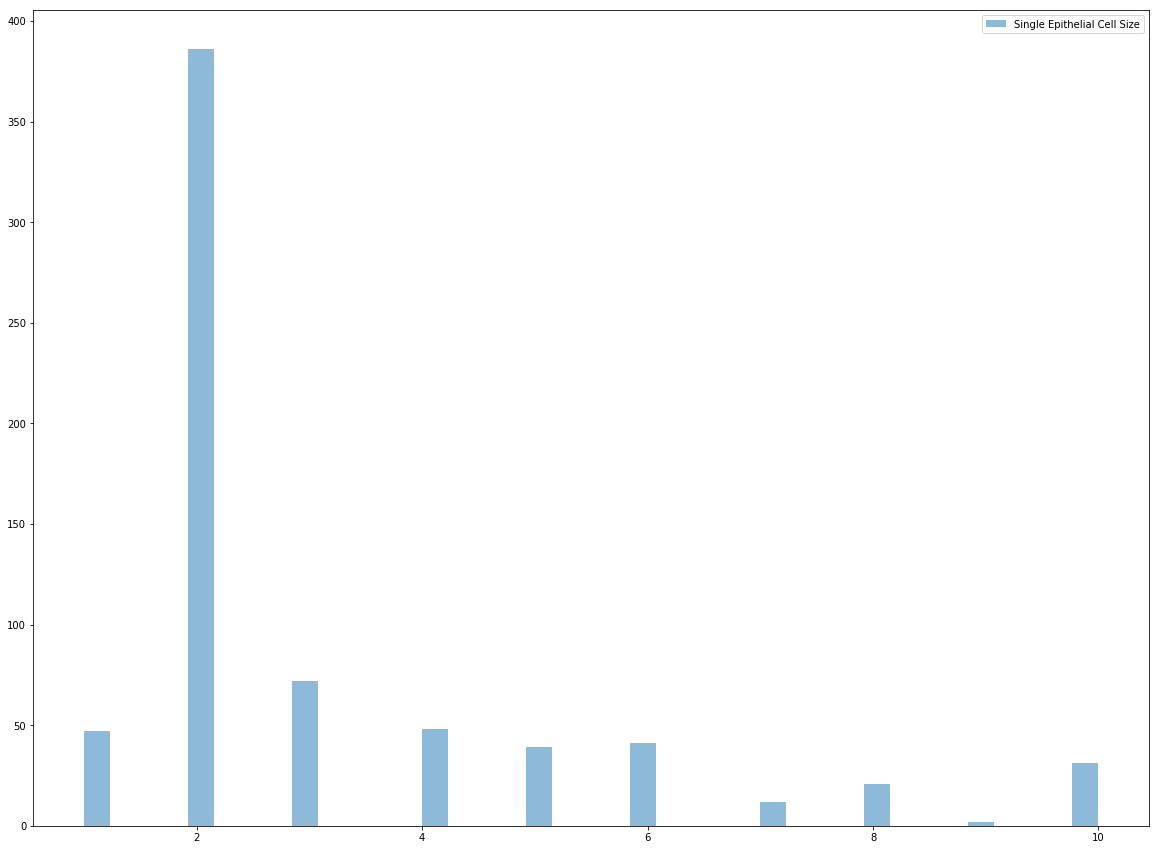

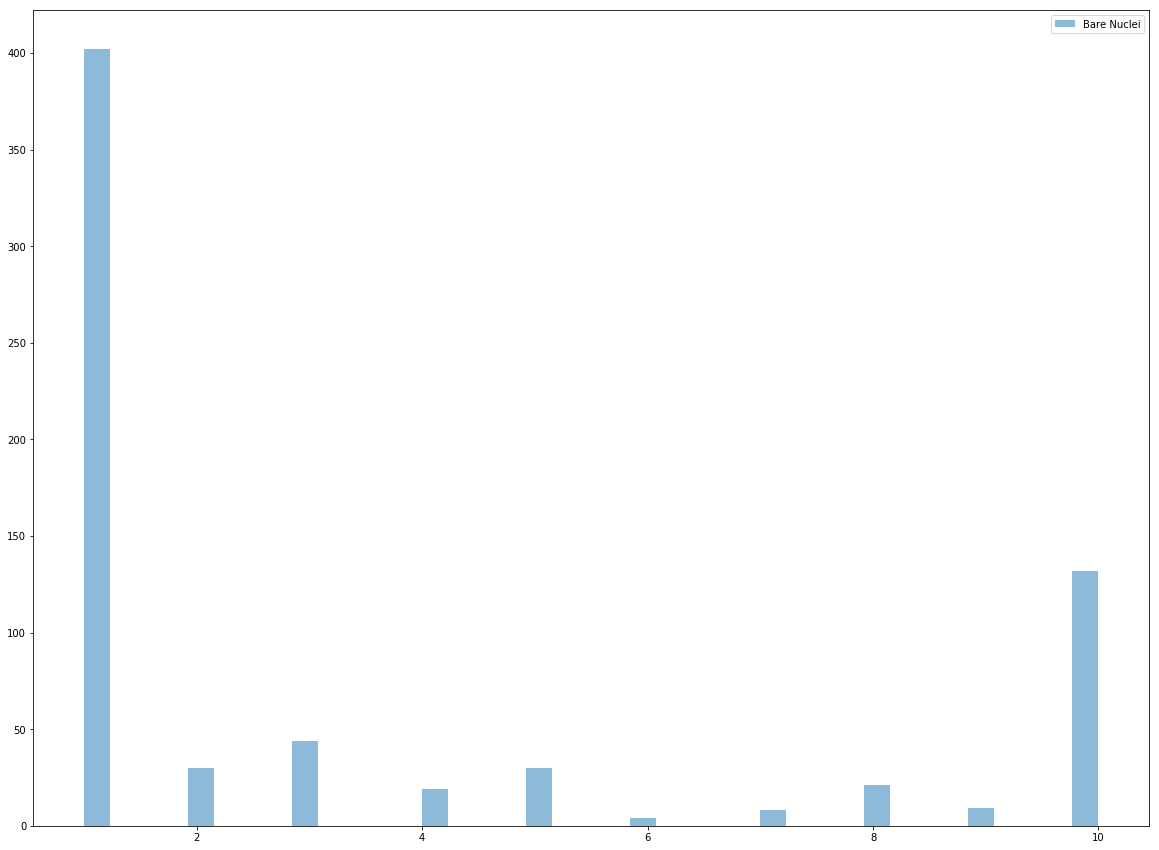

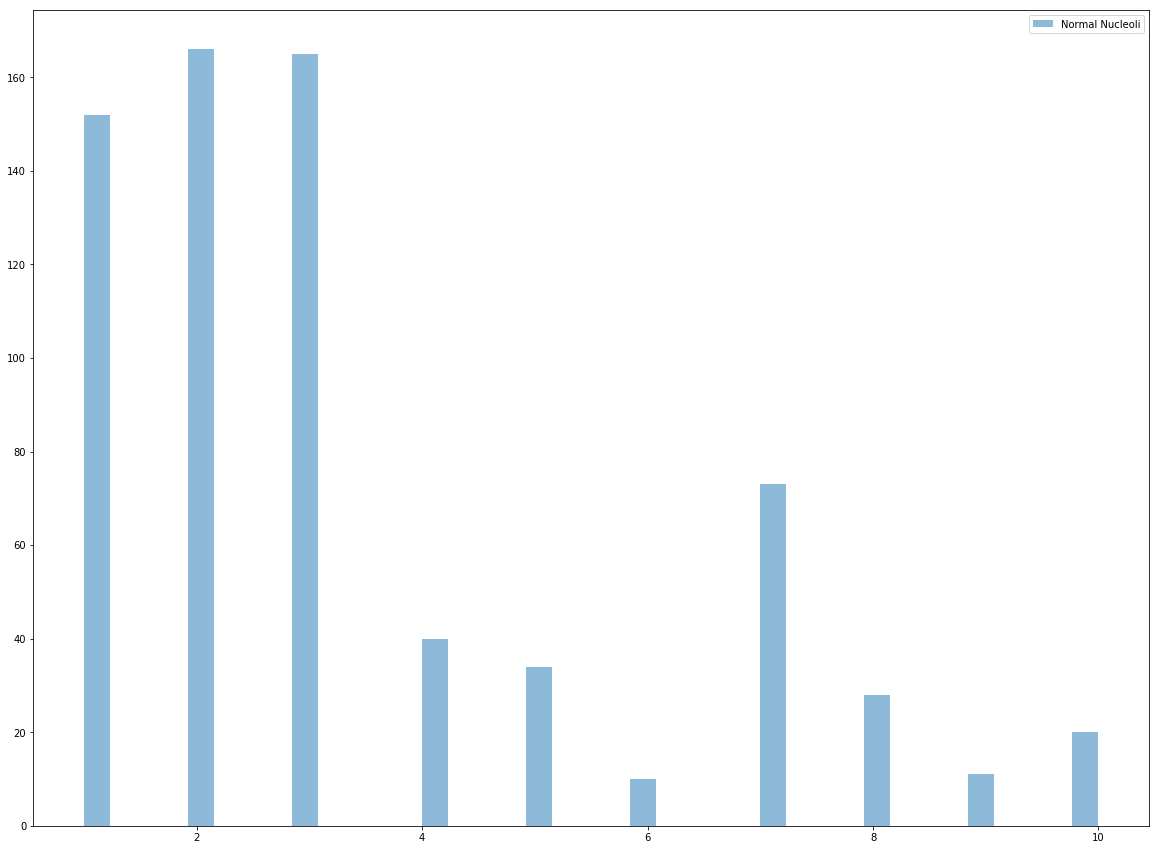

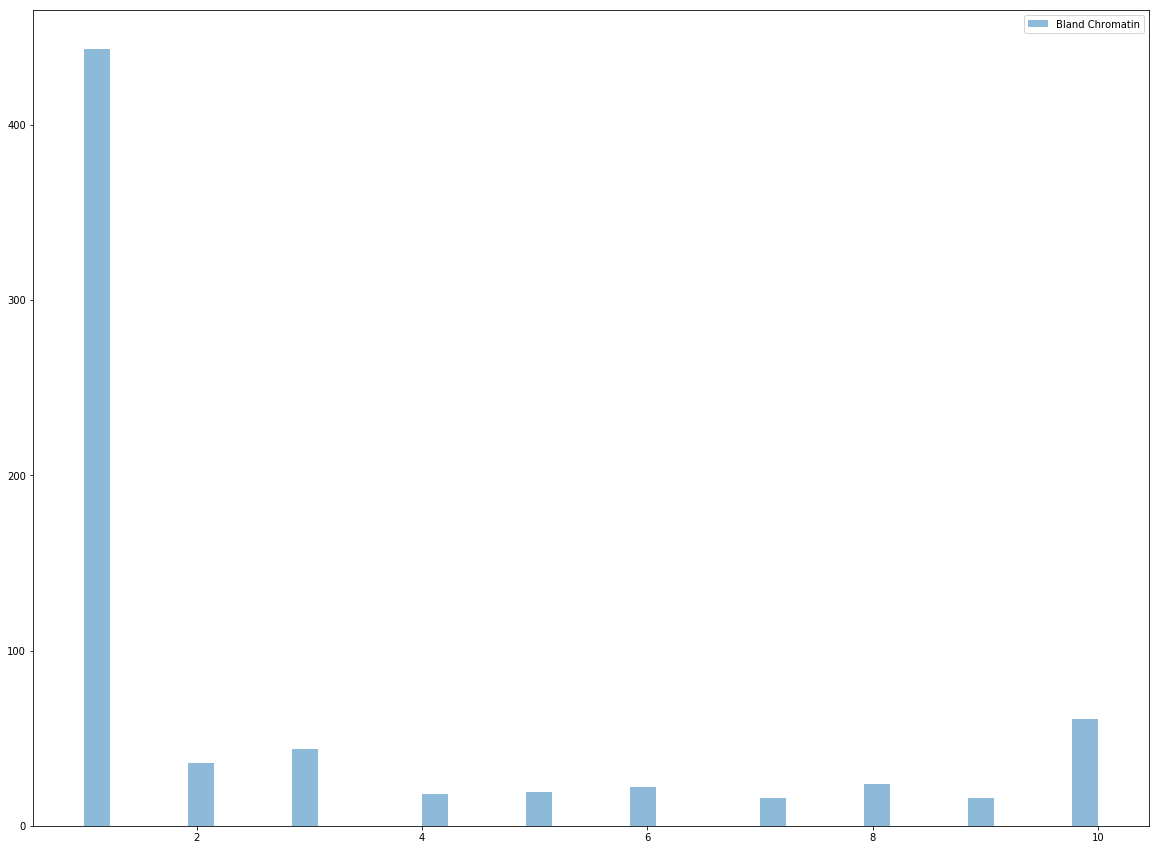

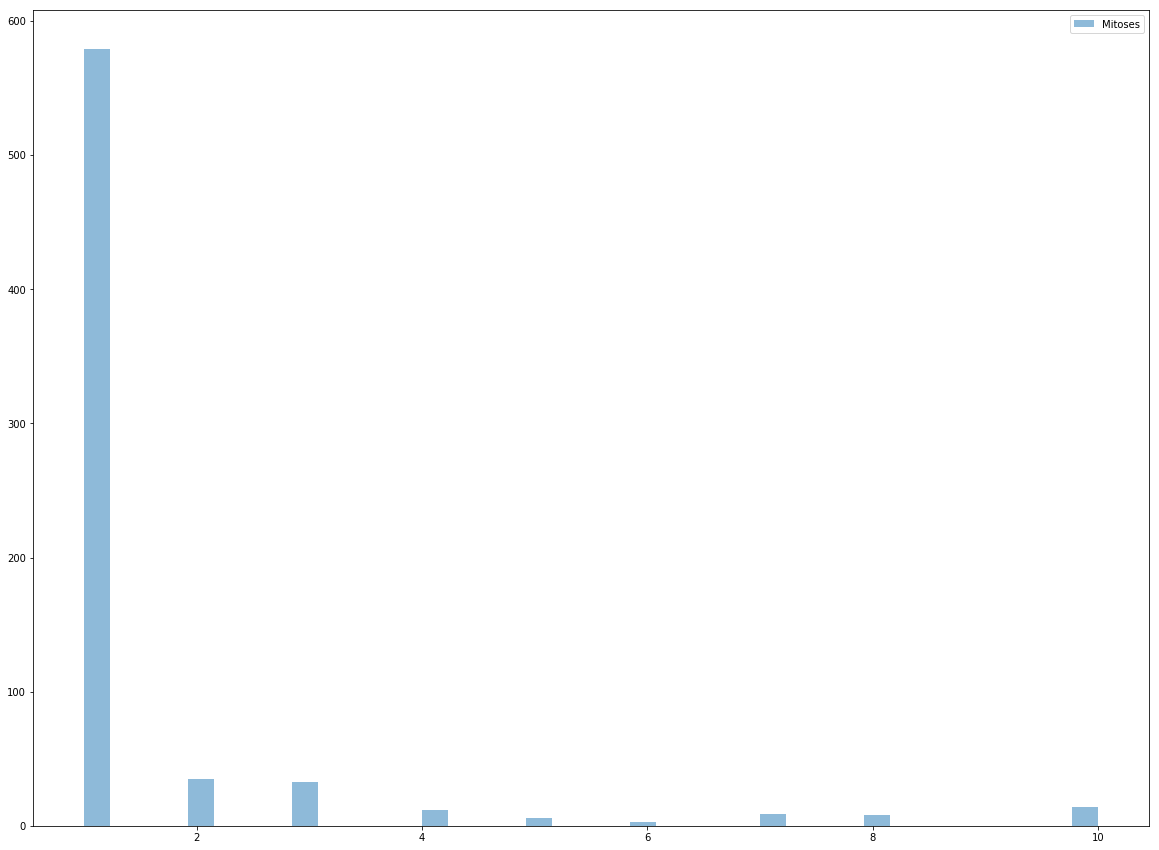

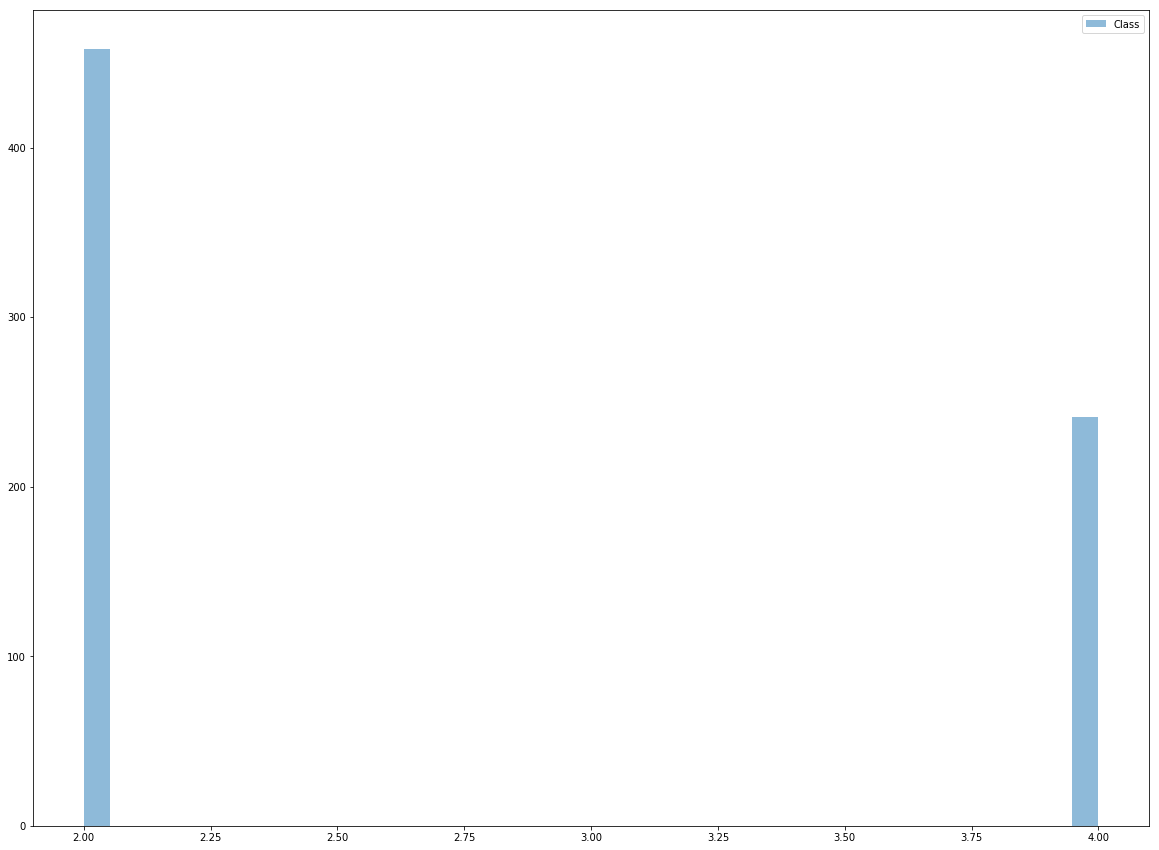

In [194]:
#Now call this function on the original dataframe above
show_quant_feature_hist_plot(cancer_df)

In [195]:
#With above almost freq-count type histogram shows that all features are categorical variables...there is no "OUTLIERS" here

C:\Users\ojhaj\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:645: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\ojhaj\Anaconda3\lib\site-packages\sklearn\base.py:464: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


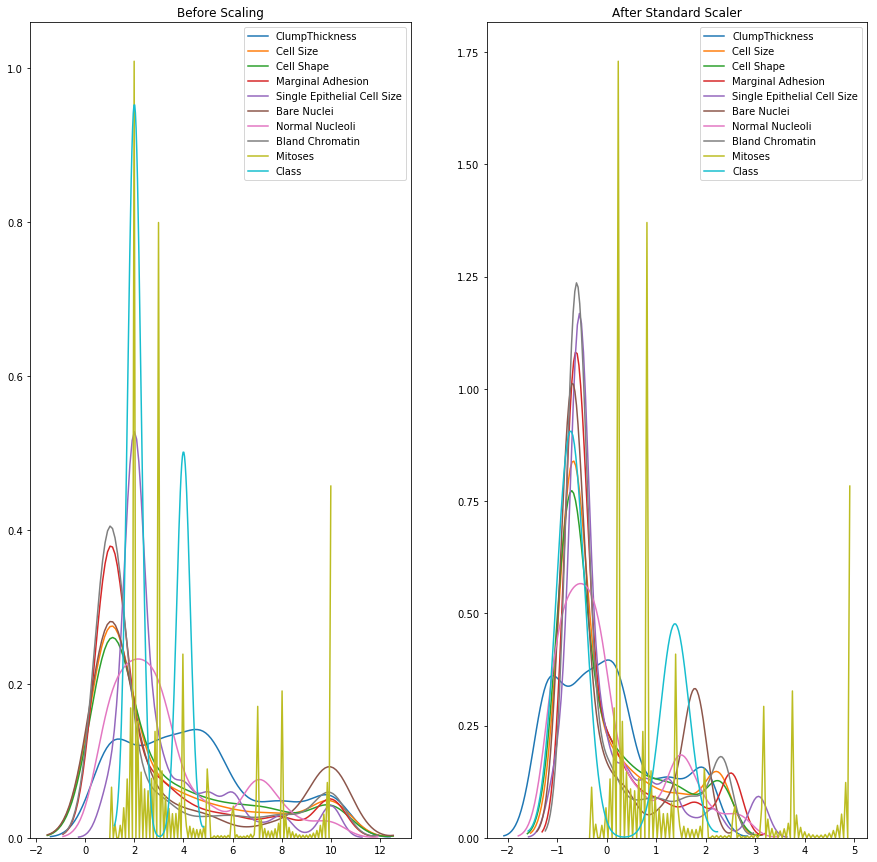

In [196]:
# We could see most of the outliers are now removed.
from sklearn import preprocessing
descr_trans_df = cancer_df.describe()
scaler = preprocessing.StandardScaler()
scaled_X = scaler.fit_transform(cancer_df[list(descr_trans_df.T.index)])
scaled_X = pd.DataFrame(scaled_X, columns=list(descr_trans_df.T.index))
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(15, 15))
ax1.set_title('Before Scaling')
for i in list(descr_trans_df.T.index)[0:10]:
    sns.kdeplot(cancer_df[i], ax=ax1)
ax2.set_title('After Standard Scaler')
for i in list(descr_trans_df.T.index)[0:10]:
    sns.kdeplot(scaled_X[i], ax=ax2)
plt.show()

In [197]:
#The above distributions wrongly indicate the "outlier type" property foer the attributes, while it is evident from
#the histograms above that all attributes actually are categorical variables.

# Q6 Create a covariance matrix for identifying Principal components

In [198]:
# Split the wine data into separate training (70%) and test (30%) sets and then standardize it to unit variance:
original_df = cancer_df.copy()
X = cancer_df[cancer_df.columns[:-1]]
y = cancer_df["Class"]


In [199]:
# PCA
# Step 1 - Create covariance matrix
# We transform (centralize) the entire X (independent variable data) to zscores through transformation. We will create the PCA dimensions
# on this distribution. 
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_std =  sc.fit_transform(X)          
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)



Covariance Matrix 
%s [[1.00143266 0.64583645 0.65552689 0.48705303 0.52256381 0.58927575
  0.5592282  0.53660222 0.35053534]
 [0.64583645 1.00143266 0.90818117 0.70659267 0.75287621 0.68840199
  0.75680368 0.72390044 0.4593503 ]
 [0.65552689 0.90818117 1.00143266 0.68405782 0.72069948 0.7108287
  0.73700282 0.72047704 0.43953974]
 [0.48705303 0.70659267 0.68405782 1.00143266 0.60045809 0.66704
  0.66767051 0.60421681 0.41823111]
 [0.52256381 0.75287621 0.72069948 0.60045809 1.00143266 0.58316514
  0.61698451 0.62978166 0.47978787]
 [0.58927575 0.68840199 0.7108287  0.66704    0.58316514 1.00143266
  0.6771358  0.57817384 0.34033128]
 [0.5592282  0.75680368 0.73700282 0.66767051 0.61698451 0.6771358
  1.00143266 0.66683179 0.34466258]
 [0.53660222 0.72390044 0.72047704 0.60421681 0.62978166 0.57817384
  0.66683179 1.00143266 0.42894941]
 [0.35053534 0.4593503  0.43953974 0.41823111 0.47978787 0.34033128
  0.34466258 0.42894941 1.00143266]]


C:\Users\ojhaj\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:645: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\ojhaj\Anaconda3\lib\site-packages\sklearn\base.py:464: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


# Q7 Identify eigen values and eigen vector

In [200]:
# Step 2- Get eigen values and eigen vector
eigenvalues, eigenvectors, = np.linalg.eig(cov_matrix)

# eigenvectors is a 9x9 matrix
print('Eigenvectors of Cov(X): \n%s' %eigenvectors)

# eigenvalues is a 9x1 vector
print('\nEigenvalues of Cov(X): \n%s' %eigenvalues)

Eigenvectors of Cov(X): 
[[-0.30267815 -0.14326117  0.86272314  0.0012632  -0.10014079  0.06484488
   0.23398913  0.27307715 -0.00377956]
 [-0.38119621 -0.04851152 -0.01607035  0.73472437  0.20324031 -0.1370179
  -0.44811882  0.09330593  0.20654523]
 [-0.37767322 -0.08491369  0.03714495 -0.66602567  0.17251104 -0.10435368
  -0.58952066  0.01753778  0.12919265]
 [-0.33273684 -0.04408953 -0.42439217 -0.04721747 -0.46762945  0.01727694
   0.10496666  0.68216    -0.09832619]
 [-0.336271    0.16549963 -0.10695366 -0.06735997  0.38924391 -0.67291374
   0.45358504 -0.0363027  -0.17937179]
 [-0.33362463 -0.25270367 -0.00641479  0.07653501 -0.53453834 -0.12353446
  -0.0781495  -0.58781818 -0.40780773]
 [-0.34604243 -0.22960457 -0.19582479 -0.05973904 -0.01081397  0.25172566
   0.40491536 -0.28621346  0.69011805]
 [-0.33595996  0.02483019 -0.12674002  0.01854131  0.44960697  0.6464732
   0.09138302 -0.03275805 -0.49051971]
 [-0.22962249  0.90740541  0.08984127 -0.00716432 -0.24641918  0.12831988

# Q8 Find variance and cumulative variance by each eigen vector

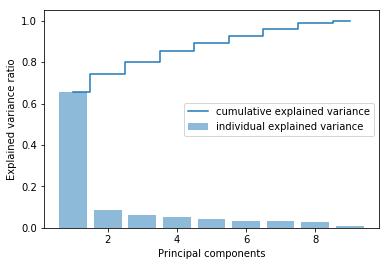

In [201]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each 
# eigen vector... there will be 8 entries as there are 8 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 8 entries with 8 th entry 
# cumulative reaching almost 100%


plt.bar(range(1,10), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,10),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()


# The plot shows that the first principal component alone accounts for 40 percent of the variance. 
# Also, we can see that the first two principal components combined explain almost 60 percent of the variance 
# in the data.

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [205]:
from sklearn.decomposition import PCA
pca = PCA(n_components=9)
pca.fit(X_std)

PCA(copy=True, iterated_power='auto', n_components=9, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [206]:
X_pca = pca.transform(X_std)

In [207]:
X_pca.shape

(699, 9)

In [208]:
X_pca_df = pd.DataFrame(X_pca)

# Q10 Find correlation between components and features

In [210]:
pca_cancer_df = X_pca_df.join(original_df)

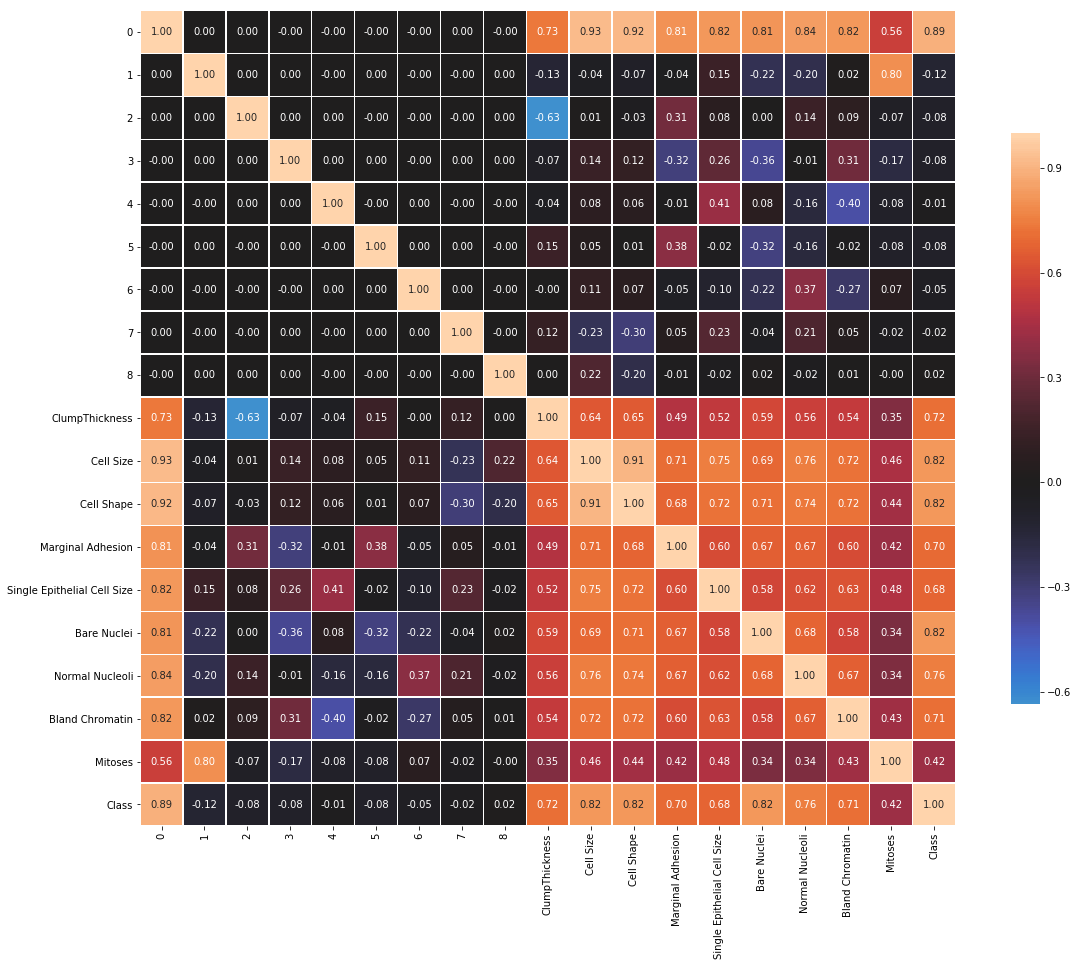

In [212]:
# Check for correlation of variable
plt.subplots(figsize=(20,15))
sns.heatmap(pca_cancer_df.corr(), vmax=1.0, center=0, fmt='.2f', square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .70})
plt.show();